In [1]:
import re
import matplotlib.pyplot as plt
import nltk
import joblib
import spacy
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             silhouette_score)
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

try:
    nlp = spacy.load("fr_core_news_sm")
except OSError:
    print("Modèle français absent. Installation en cours...")
    spacy.cli.download("fr_core_news_sm")
    nlp = spacy.load("fr_core_news_sm")

print('Environnement prêt.')

Modèle français absent. Installation en cours...
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Environnement prêt.


### Partie 1 — Exploration & Prétraitement des données

#### 1.1 Chargement et exploration

In [2]:
#Chargement des données :
data_path = "data/dataset_nlp_test_tal.csv"
raw = pd.read_csv(data_path)
df = raw.copy()

print("Dimmensions du dataset :\n")
print(df.shape)
print("Aperçu du dataset \n")
print(df.head())
print("Informations sur le dataset:\n")
print(df.info())


Dimmensions du dataset :

(150, 3)
Aperçu du dataset 

   id                                              texte       categorie
0   1  Manque total de communication entre les services.  Insatisfaction
1   2  Il serait bien de proposer des tutoriels vidéo...      Suggestion
2   3  Envoyer des SMS de confirmation lors de chaque...      Suggestion
3   4  Prévoir des interprètes pour les citoyens ne p...      Suggestion
4   5  Le formulaire en ligne plante au moment de la ...  Insatisfaction
Informations sur le dataset:

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         150 non-null    int64
 1   texte      150 non-null    str  
 2   categorie  150 non-null    str  
dtypes: int64(1), str(2)
memory usage: 14.7 KB
None


In [3]:
pd.set_option('display.max_colwidth', None)
df[["texte","categorie"]].sample(15)

,texte,categorie
63,Des agents de terrain pourraient sensibiliser dans les marchés locaux.,Suggestion
62,Le formulaire en ligne est intuitif et facile à remplir.,Satisfaction
94,"Très bien, le délai de traitement est raisonnable.",Satisfaction
50,Des agents mobiles pourraient servir les zones rurales éloignées.,Suggestion
60,Le nouveau système en ligne facilite vraiment les démarches.,Satisfaction
41,Une application mobile dédiée faciliterait les démarches pour tous.,Suggestion
34,Mettre en réseau les différentes mairies pour un meilleur partage des données.,Suggestion
14,J'ai dû payer un intermédiaire pour que mon dossier avance.,Insatisfaction
64,"Service honnête et transparent, merci.",Satisfaction
25,Publier les résultats des enquêtes de satisfaction pour plus de transparence.,Suggestion


Text(0.5, 1.0, 'Distributions des classes de la colonne categorie.')

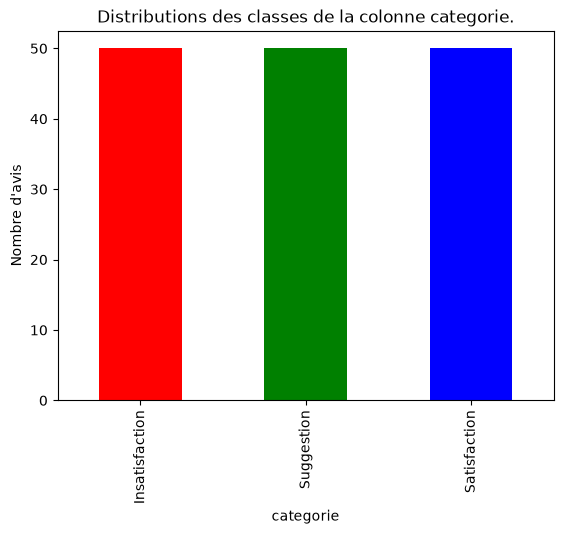

In [4]:
#Distribution des classes

classes_distributions = df['categorie'].value_counts()
classes_distributions.plot(kind="bar",color = ['red','green','blue'])
plt.ylabel("Nombre d'avis")
plt.title("Distributions des classes de la colonne categorie.")

#### On remarque que les classes de notre dataset sont equilibrés c'est a dire **50** observations pour chaque classes

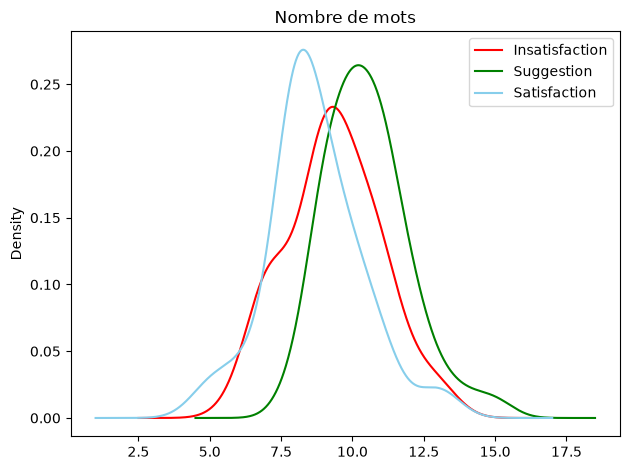

Longueur moyenne des mots par categorie:



categorie
Insatisfaction     9.34
Satisfaction       8.68
Suggestion        10.50
Name: nb_mots, dtype: float64

In [5]:

df['nb_mots'] = df['texte'].apply(lambda x: len(x.split()))

df[df['categorie'] == 'Insatisfaction']['nb_mots'].plot(kind='kde', color='red', label='Insatisfaction')
df[df['categorie'] == 'Suggestion']['nb_mots'].plot(kind='kde', color='green', label='Suggestion')
df[df['categorie'] == 'Satisfaction']['nb_mots'].plot(kind='kde', color='skyblue', label='Satisfaction')

plt.title('Longueur des avis (nombre de mots)')
plt.title('Nombre de mots')
plt.legend()
plt.tight_layout()
plt.show()

#Longueur moyenne des textes par categorie

print("Longueur moyenne des mots par categorie:\n")
df.groupby("categorie")["nb_mots"].mean()

#### 1.2 Nettoyage du texte

In [6]:
#Mise du texte en miniscule
def to_lower(texte):
    texte = texte.lower()
    return texte

df['texte'] = df['texte'].apply(to_lower)
df.head(5)

,id,texte,categorie,nb_mots
0,1,manque total de communication entre les services.,Insatisfaction,7
1,2,il serait bien de proposer des tutoriels vidéo pour les démarches en ligne.,Suggestion,13
2,3,envoyer des sms de confirmation lors de chaque étape du traitement.,Suggestion,11
3,4,prévoir des interprètes pour les citoyens ne parlant pas le français.,Suggestion,11
4,5,le formulaire en ligne plante au moment de la soumission.,Insatisfaction,10


In [7]:
#suprimer la ponctuation les chiffres et les caracteres speciaux

def clean(texte):
    texte = re.sub(r'[^\w\s]',   ' ', texte)  # ponctuation et caractères spéciaux
    texte = re.sub(r'\d+',       ' ', texte)  # Chiffres
    return texte

df['texte'] = df['texte'].apply(clean)
df.sample(5)
    


,id,texte,categorie,nb_mots
107,108,processus transparent j ai pu suivre l avancement de mon dossier,Satisfaction,9
30,31,mon dossier traîne depuis semaines sans réponse,Insatisfaction,8
142,143,il faudrait un système automatisé de rappel de rendez vous par sms,Suggestion,11
79,80,personnel peu formé sur les nouvelles procédures en vigueur,Insatisfaction,9
5,6,le personnel semble débordé et les citoyens en pâtissent,Insatisfaction,9


In [8]:
import re, unicodedata
import pandas as pd
from collections import Counter
from wordfreq import zipf_frequency      

# Signal 1 (certain) : lettres propres à l'alphabet éwé
CARACTERES_EWE = set("ɖɛƒɣŋɔʋ")
# Signal 2 (probable) : suites de lettres typiques de l'éwé en alphabet simple
MOTIFS_EWE = ("kp", "gb", "dz", "ny", "ts")
# Fréquence zipf (wordfreq) en dessous de laquelle un mot est « rare en français »
SEUIL_FR = 2.0

def classer_mot(mot):
    if CARACTERES_EWE & set(mot):
        return "ewe"                             # lettre éwé : détection certaine
    if mot.isdigit():
        return "fr"                                  # les nombres ne sont pas à vérifier
    freq = zipf_frequency(mot, "fr")
    if freq < SEUIL_FR and any(m in mot for m in MOTIFS_EWE):
        return "ewe_probable"                  # motif éwé ET mot rare en français
    if freq == 0:
        return "inconnu"                      # inconnu du français, sans motif : à relire
    return "fr"

def traiter_ewe(texte, jeton="motewe"):
    """Remplace les mots éwé (certains ou probables) par un jeton neutre.
    Retourne (texte_traité, mots_éwé, mots_inconnus)."""
    if pd.isna(texte):
        return "", [], []
    texte = unicodedata.normalize("NFC", str(texte)).lower()
    mots = re.findall(r"[\w\u0300-\u036f]+", texte)
    labels = [classer_mot(m) for m in mots]
    texte_traite = " ".join(jeton if l.startswith("ewe") else m for m, l in zip(mots, labels))
    return (texte_traite,
            [m for m, l in zip(mots, labels) if l.startswith("ewe")],
            [m for m, l in zip(mots, labels) if l == "inconnu"])

resultats = df["texte"].apply(traiter_ewe)
df["texte_traite"]  = [r[0] for r in resultats]
df["mots_ewe"]      = [r[1] for r in resultats]
df["mots_inconnus"] = [r[2] for r in resultats]
df["contient_ewe"]  = df["mots_ewe"].apply(bool)

# Diagnostic
print(df["contient_ewe"].sum(), "avis sur", len(df))
print("Éwé détecté :", Counter(m for ms in df["mots_ewe"] for m in ms).most_common(30))
print("Inconnus    :", Counter(m for ms in df["mots_inconnus"] for m in ms).most_common(30))

3 avis sur 150
Éwé détecté : [('nyuie', 1), ('mègbe', 1), ('akpe', 1)]
Inconnus    : [('yèvu', 1), ('hafi', 1), ('wò', 1)]


#### D'apres l'analyse le nombre de mot ewe n'est pas très conséquent.
 **Pour la suite du travail on choisis simplement  de les ignorés puise que les modeles d'embeddings n'en tienne pas compte.**

In [9]:
# Suppression des stopwords
import nltk
nltk.download ('stopwords')
from nltk.corpus import stopwords


#Taille des mots vides dans le vocaulaire
stop_nltk = set ( stopwords.words('french') )
print ( len ( stop_nltk ) )

#Liste des mots vides
stop_nltk = list ( stop_nltk )
print (stop_nltk[:15])


157
['sa', 'au', 'soyons', 'sur', 'aurions', 'aies', 'à', 's', 'avaient', 'elle', 'fussions', 'fussiez', 'ayante', 'nous', 'étants']


[nltk_data] Downloading package stopwords to C:\Users\Ce
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Deux principaux bibliothèques fournissent une liste pré -établi des mots vides : `nltk` et `spacy`
nltk qui est assez compatible avec le français et gere mieux la subtilité de la langue française.
Nous allons constituer une liste aggreger des stopword des deux bibliotheques pour avoir une liste exhaustive.

In [10]:
import spacy

nlp = spacy.load('fr_core_news_sm')

stop_spacy = nlp.Defaults.stop_words
print(f'SpaCy : {len(stop_spacy)} stopwords')
print(f'Stopwords : {list(stop_spacy)[:15]}')

SpaCy : 507 stopwords
Stopwords : ['dejà', 'hui', 'soi', 'tiennes', 'enfin', 'sur', 'ah', 'suffisante', 'mienne', 'à', 'déjà', 'elle-même', 'laisser', 'parlent', 'mêmes']


In [11]:
stop_fr = set(stop_nltk) | stop_spacy  # union des deux listes
print(f'Total : {len(stop_fr)} stopwords')

Total : 579 stopwords


In [12]:
#Suppression des stop words
def removes_stops(texte, stop_fr):
    tokens = texte.split()
    return [t for t in tokens if t.lower() not in stop_fr]

In [13]:
# Prendre une copie du dataset original pour pouvoir comparer
df2 = raw.copy()

print("Avant suppression des mots vides :")
display(df2.head(3))

df['tokens'] = df['texte'].apply(lambda x: removes_stops(x, stop_fr))

print("\nAprès suppression des mots vides :")
display(df[['texte', 'tokens']].head(3))

Avant suppression des mots vides :


,id,texte,categorie
0,1,Manque total de communication entre les services.,Insatisfaction
1,2,Il serait bien de proposer des tutoriels vidéo pour les démarches en ligne.,Suggestion
2,3,Envoyer des SMS de confirmation lors de chaque étape du traitement.,Suggestion



Après suppression des mots vides :


,texte,tokens
0,manque total de communication entre les services,"[manque, total, communication, services]"
1,il serait bien de proposer des tutoriels vidéo pour les démarches en ligne,"[bien, proposer, tutoriels, vidéo, démarches, ligne]"
2,envoyer des sms de confirmation lors de chaque étape du traitement,"[envoyer, sms, confirmation, étape, traitement]"


Cette methode peut avoir des limites puise qu'on ne fait pas une tokenization en tant que telle mais on supprime seulement les stop words.
Il faudra tester une methode de tokenization pour vraiment capture le sens des mots.

In [14]:
#Utilisons la tokenization pour diviser le texte en mots et phrases. Nous allons utiliser la bibliothèque NLTK pour cela.

#Nous allons utiliser la fonction word_tokenize qui retourne une tokenization du texte en mots.
from nltk.tokenize import word_tokenize

def tokenize(text):
  tokens = word_tokenize(text, language='french')
  tokens = [t.lower() for t in tokens if t.isalpha() and len(t) > 2]
  tokens = [t for t in tokens if t not in stop_fr]
  return tokens

# Appliquer sur nos avis
df['texte_tokenize'] = df['texte'].apply(tokenize)
df[["texte","tokens","texte_tokenize"]].head(3)

,texte,tokens,texte_tokenize
0,manque total de communication entre les services,"[manque, total, communication, services]","[manque, total, communication, services]"
1,il serait bien de proposer des tutoriels vidéo pour les démarches en ligne,"[bien, proposer, tutoriels, vidéo, démarches, ligne]","[bien, proposer, tutoriels, vidéo, démarches, ligne]"
2,envoyer des sms de confirmation lors de chaque étape du traitement,"[envoyer, sms, confirmation, étape, traitement]","[envoyer, sms, confirmation, étape, traitement]"


#### 1.3 Visualisations

In [15]:
#nuage de mots (wordcloud) par catégorie
figures_dir = "figures_dir/"
def wordcloud(categorie):
    words = df[df['categorie'] == categorie]['texte_tokenize'].replace("", pd.NA).dropna().astype(str).tolist()
    if not words:
        print(f'Aucun mot pour la categorie {categorie}')
        return

    text = " ".join(words)
    wc = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Wordcloud pour la catégorie : {categorie}')
    plt.axis('off')
    out = figures_dir / f'wordcloud_{categorie}.png'
    plt.tight_layout()
    plt.savefig(out, dpi=200)


Wordcloud de la categorie Insatisfaction :
Wordcloud de la categorie Suggestion :
Wordcloud de la categorie Satisfaction :


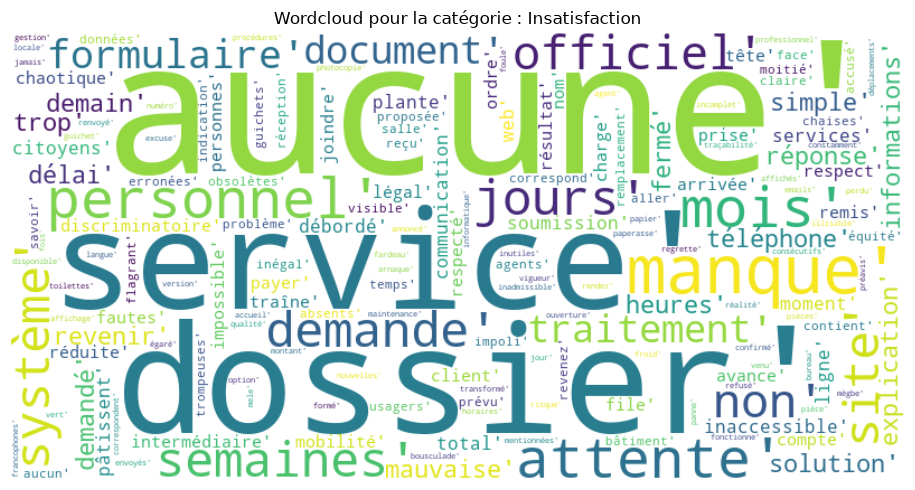

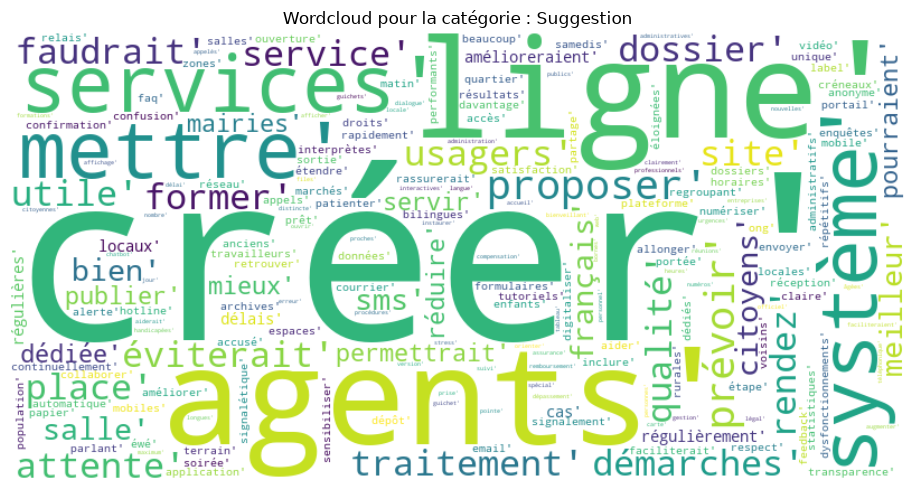

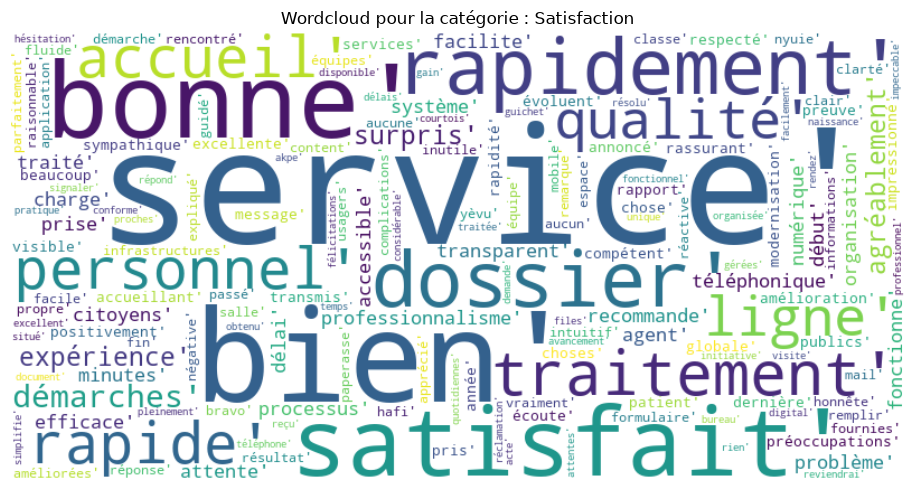

In [16]:

categories = ["Insatisfaction","Suggestion","Satisfaction"]

for categorie in categories:
    print(f'Wordcloud de la categorie {categorie} :')
    figures_dir = Path(figures_dir)
    figures_dir.mkdir(parents=True, exist_ok=True)

    wordcloud(categorie)

In [17]:
#les 15 termes les plus fréquents par catégorie

top_15_Insatisfaction = df[df['categorie'] == 'Insatisfaction']['texte_tokenize'].explode().value_counts().head(15)
top_15_Suggestion = df[df['categorie'] == 'Suggestion']['texte_tokenize'].explode().value_counts().head(15)
top_15_Satisfaction = df[df['categorie'] == 'Satisfaction']['texte_tokenize'].explode().value_counts().head(15)
top_15 = {"Insatisfaction":top_15_Insatisfaction, "Suggestion":top_15_Suggestion, "Satisfaction":top_15_Satisfaction}
for categorie,top in top_15.items():
    print("\n les 15 termes les plus fréquents pour la catégorie ", categorie)
    print(top)


 les 15 termes les plus fréquents pour la catégorie  Insatisfaction
texte_tokenize
aucune        10
dossier        6
service        5
manque         4
personnel      4
attente        4
mois           4
site           3
jours          3
système        3
semaines       3
demande        3
officiel       3
non            3
formulaire     2
Name: count, dtype: int64

 les 15 termes les plus fréquents pour la catégorie  Suggestion
texte_tokenize
créer         6
ligne         5
agents        5
services      5
mettre        5
système       5
proposer      4
prévoir       4
démarches     3
traitement    3
former        3
usagers       3
attente       3
rendez        3
place         3
Name: count, dtype: int64

 les 15 termes les plus fréquents pour la catégorie  Satisfaction
texte_tokenize
service         14
bien             8
bonne            5
satisfait        4
rapidement       4
dossier          4
traitement       3
personnel        3
rapide           3
accueil          3
qualité          

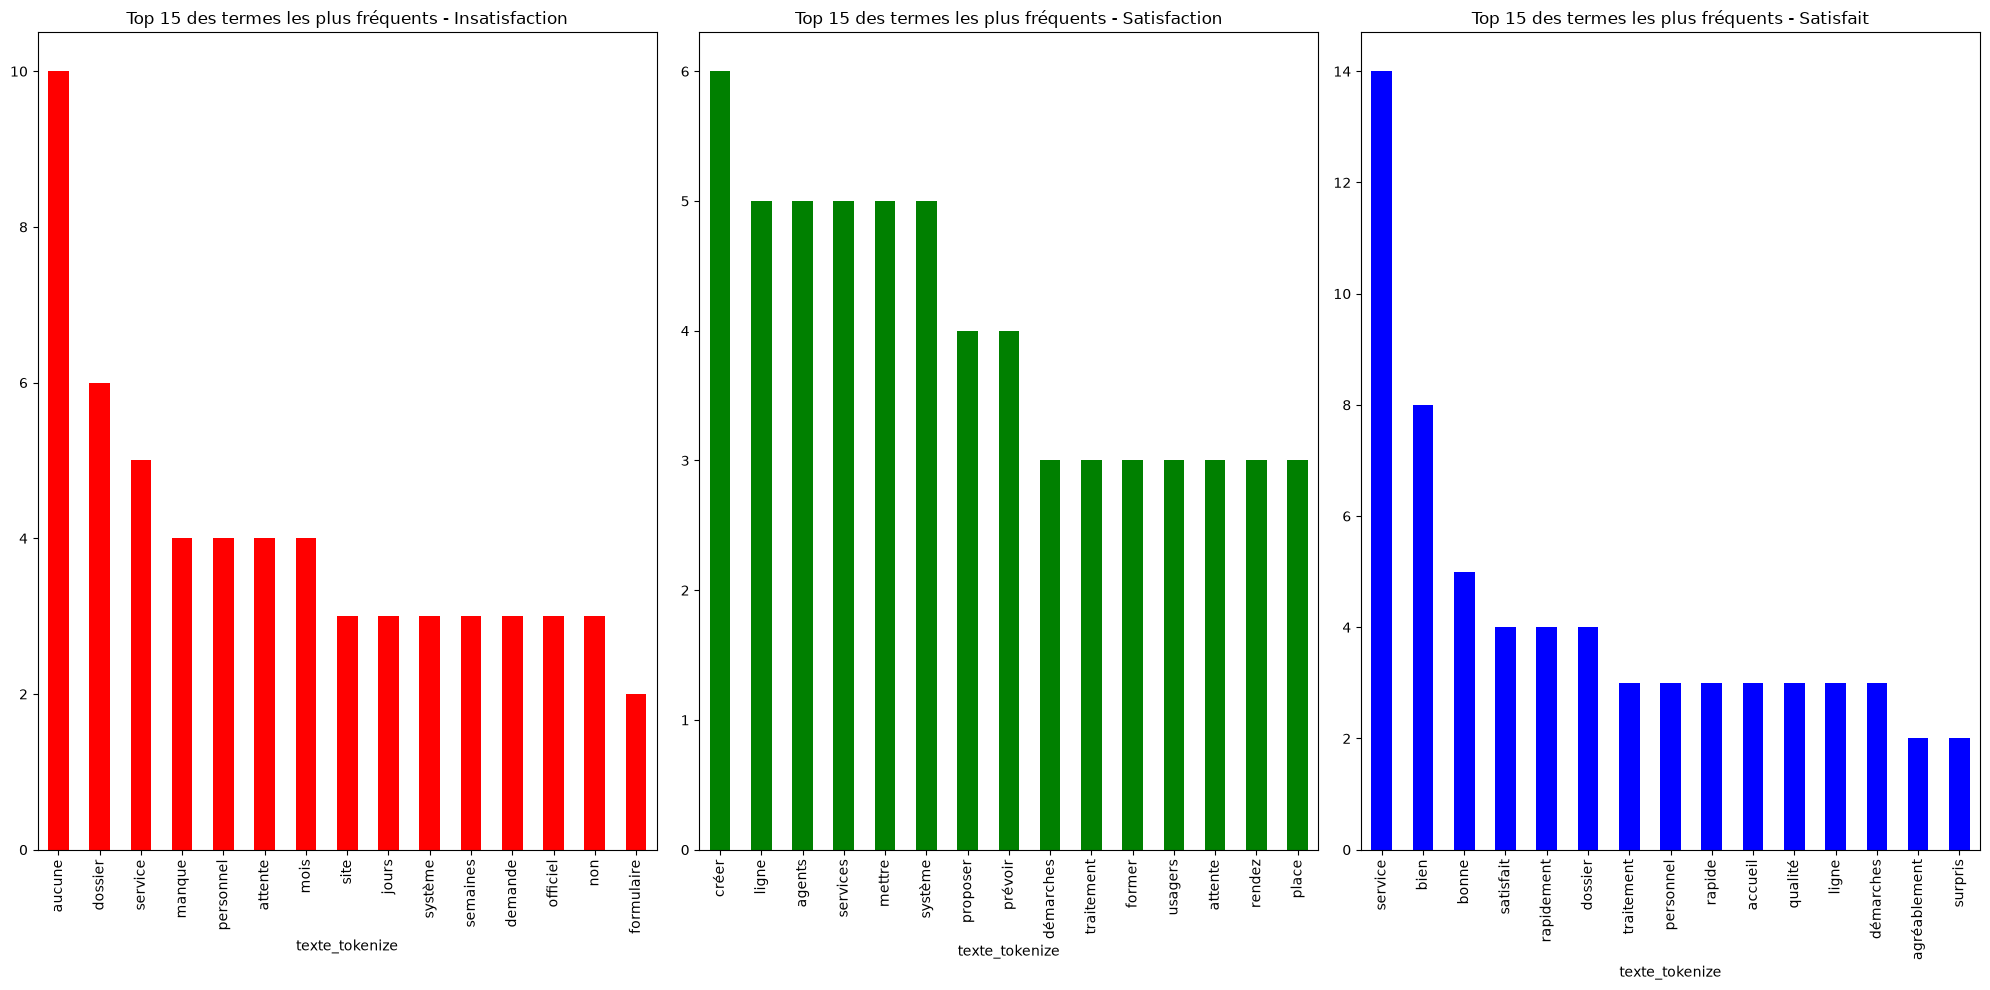

In [18]:
# AFfichage des termes les plus fréquents par categorie
fig,axes = plt.subplots(1,3,figsize=(20, 10))
top_15_Insatisfaction.plot(kind='bar',ax=axes[0], color='red', title='Top 15 des termes les plus fréquents - Insatisfaction')
top_15_Suggestion.plot(kind='bar',ax=axes[1], color='green', title='Top 15 des termes les plus fréquents - Satisfaction')
top_15_Satisfaction.plot(kind='bar',ax=axes[2], color='blue', title='Top 15 des termes les plus fréquents - Satisfait')

out = figures_dir / f'Frequence_termes_par_categorie.png'
plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

### Partie 2 — Modélisation

#### 2.1 Vectorisation
Les modèles de machine learning travaillent avec des **nombres**, pas du texte. La vectorisation transforme chaque texte en un vecteur numérique. ILs existe trois principale approche dont le choix depend du travail demander et du contexte :

| Méthode | Vecteur | Capture le sens ? |
|---|---|---|
| Bag of Words | Creux (sparse) | Non |
| TF-IDF | Creux (sparse) | Non (fréquence) |
| Embeddings | Dense | Oui |

Nous allons explorer le TF-IDF en baseline puis tester des Embeddings avant de conclure et de faire un choix de la meilleur strategie.

##### a. TF-IDF

Le **TF-IDF** (*Term Frequency – Inverse Document Frequency*) pondère chaque mot selon sa fréquence dans le document (TF) et sa rareté dans le corpus (IDF). Un mot très fréquent dans un texte mais rare dans les autres obtient un score élevé — contrairement aux mots courants comme "le", "de", etc.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
textes = df['texte_tokenize'].apply(lambda tokens: ' '.join(tokens))

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(textes)

print(f"Taille de la matrice TF-IDF : {X_tfidf.shape}")
print(f"Exemple de mots : {tfidf.get_feature_names_out()[:10]}")

Taille de la matrice TF-IDF : (150, 457)
Exemple de mots : ['absents' 'accessible' 'accompagnement' 'accueil' 'accueillant' 'accusé'
 'accès' 'acte' 'administratifs' 'administration']


##### b. Bag of Words (BoW)

Le **Bag of Words** construit un vocabulaire global puis représente chaque texte par le **nombre d'occurrences** de chaque mot de ce vocabulaire. L'ordre des mots est totalement ignoré.

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(textes)

print(f"Taille de la matrice BoW : {X_bow.shape}")
print(f"Exemple de mots du vocabulaire : {bow.get_feature_names_out()[:10]}")

Taille de la matrice BoW : (150, 457)
Exemple de mots du vocabulaire : ['absents' 'accessible' 'accompagnement' 'accueil' 'accueillant' 'accusé'
 'accès' 'acte' 'administratifs' 'administration']


#### c. Embeddings — Word2Vec

**Word2Vec** est un modèle neuronal qui apprend des représentations vectorielles denses (*embeddings*) à partir du contexte des mots dans le corpus. Contrairement à BoW/TF-IDF, il capture le **sens** : *film* et *cinéma* auront des vecteurs proches.

Deux architectures d'entraînement existent :

| Architecture | Principe | Adapté à |
|---|---|---|
| **CBOW** | Prédit le mot central à partir des mots du contexte | Grands corpus |
| **Skip-gram** | Prédit les mots du contexte à partir du mot central | Petits corpus, mots rares |


Nous choisissons de partir sur wordvec en baseline mais il existe divers modeles d'embbbedings encore plus performants.

In [21]:
from gensim.models import Word2Vec

# Corpus : liste de listes de tokens (déjà calculé à l'étape Tokenisation)
corpus = df['texte_tokenize'].tolist()

# CBOW (sg=0) : prédit le mot central à partir des mots environnants
cbow = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=2, sg=0, epochs=10)

print(f"Vocabulaire : {len(cbow.wv)} mots  |  Dimension : {cbow.vector_size}")


Vocabulaire : 136 mots  |  Dimension : 100


#### Nous partons sur du TF-IDF en baseline

In [22]:
#SPlit de l'ensemble de données en ensembles d'entraînement et de test
y = df['categorie']

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

#### 2.2 Entraînement

In [23]:
#Naives bayes
naive = MultinomialNB()
naive.fit(X_train, y_train)

#Regression logistic
logreg = LogisticRegression(max_iter=1000,random_state=42)
logreg.fit(X_train, y_train)

#support vector machines
svm = LinearSVC(max_iter=10000,random_state=42)
svm.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",10000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are s

#### 2.3 Évaluation

In [24]:
def evaluate( model, X_test, y_test, model_name: str):
    """
        Évalue un modèle et affiche les métriques.

        Affiche :
        - Accuracy
        - F1-score macro et pondéré
        - Rapport de classification complet
        - Matrice de confusion (graphique)

        Sauvegarde : figuress_dir/confusion_{model_name}.png

        Args:
            model      : Modèle entraîné
            X_test     : Données de test
            y_test     : Étiquettes réelles
            model_name : Nom du modèle 
    """
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    print(f"Évaluation {model_name}:")
    print(classification_report(y_test, y_pred))

        # matrice de confusion
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f'Matrice de confusion - {model_name}')
    plt.savefig(figures_dir / f'confusion_{model_name.replace(" ","_")}.png')
    plt.show()
    results = {}
        # stocker les métriques
    results[model_name] = {
            'accuracy': report.get('accuracy', None),
            'f1_macro': report.get('macro avg', {}).get('f1-score', None),
            'f1_weighted': report.get('weighted avg', {}).get('f1-score', None),
        }
    return results

def compare_models(results):
    """
        Affiche un tableau comparatif des performances de tous les modèles
        entraînés (accuracy, F1-macro, F1-pondéré).

        Sauvegarde : figures_dir/comparaison_classifieurs.png
    """
    df = pd.DataFrame(results).T
    print(df)
    plt.figure()
    df[['accuracy','f1_macro','f1_weighted']].plot(kind='bar')
    plt.tight_layout()
    plt.savefig(figures_dir / 'comparaison_classifieurs.png')
    plt.show()


debut de l'evaluation du modele :naives-bayes : 

Évaluation naives-bayes:
                precision    recall  f1-score   support

Insatisfaction       0.44      0.36      0.40        11
  Satisfaction       0.45      0.42      0.43        12
    Suggestion       0.50      0.71      0.59         7

      accuracy                           0.47        30
     macro avg       0.47      0.50      0.47        30
  weighted avg       0.46      0.47      0.46        30



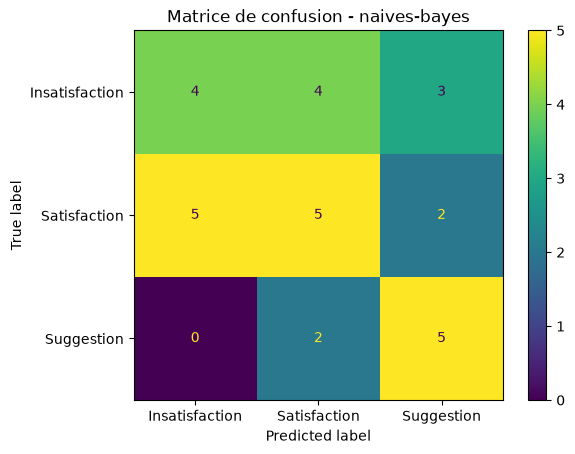

debut de l'evaluation du modele :logistic Reegression : 

Évaluation logistic Reegression:
                precision    recall  f1-score   support

Insatisfaction       0.56      0.45      0.50        11
  Satisfaction       0.62      0.42      0.50        12
    Suggestion       0.46      0.86      0.60         7

      accuracy                           0.53        30
     macro avg       0.55      0.58      0.53        30
  weighted avg       0.56      0.53      0.52        30



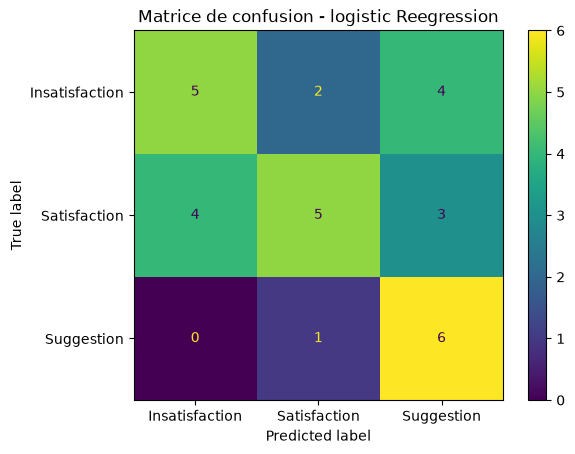

debut de l'evaluation du modele :svm : 

Évaluation svm:
                precision    recall  f1-score   support

Insatisfaction       0.56      0.45      0.50        11
  Satisfaction       0.60      0.50      0.55        12
    Suggestion       0.45      0.71      0.56         7

      accuracy                           0.53        30
     macro avg       0.54      0.56      0.53        30
  weighted avg       0.55      0.53      0.53        30



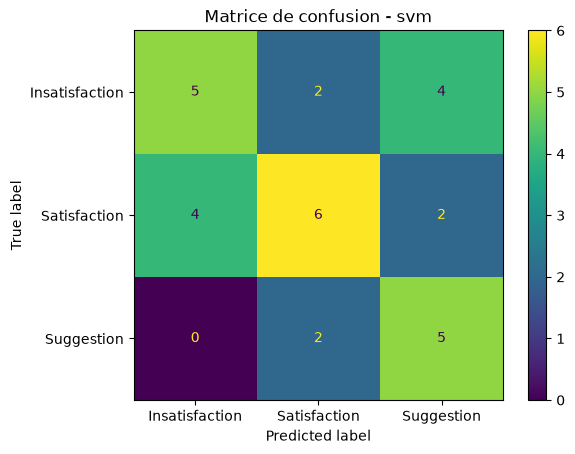

In [25]:
modeles = {"naives-bayes":naive,"logistic Reegression": logreg, "svm":svm}
results = {}
for name,modele in modeles.items():
    print(f"debut de l'evaluation du modele :{name} : \n")
    print("========================================")
    results.update(evaluate(modele, X_test, y_test, name))
    


                      accuracy  f1_macro  f1_weighted
naives-bayes          0.466667  0.474339     0.457835
logistic Reegression  0.533333  0.533333     0.523333
svm                   0.533333  0.533670     0.531145


<Figure size 640x480 with 0 Axes>

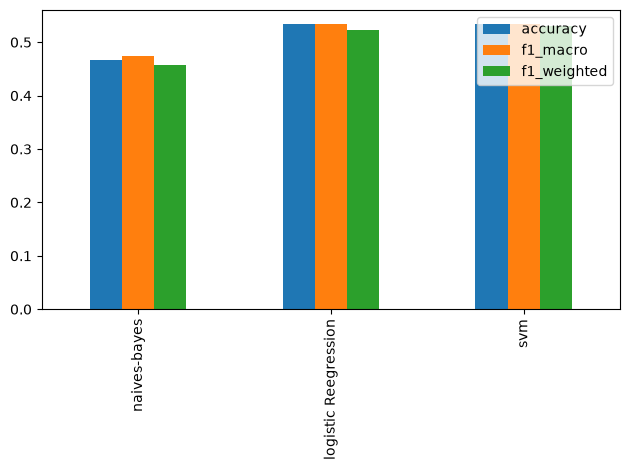

In [26]:
#Comparaisons des modèles dans un tableau de synthèse
compare_models(results)

##### Commentaire:
Sur Les trois modeles Le modele avec le meilleur score f1_macro est le support vector machine (svm) qui a des résultats similaire au logistic Regression.
En obseravant la matrice de confusion du svm on remarque que:
1. Sur les 11 avis d'insatisfactions , 5 ont été correctement classés, 2 ont été classés dans la classe satisfaction et 4 dans la Classe suggestion(sur les 11 exmples le modele en a correctement classé seulement 5)
2. Sur les 12 avis de satisfactions , 6 ont été correctement classés, 4 ont été classés dans la classe insatisfaction et 2 dans la Classe suggestion(sur les 12 exmples le modele en a correctement classé 6)
3. Sur les 7 avis de suggestion , 5 ont été correctement classés, 2 ont été classés dans la classe satisfaction et aucune n'a été mise dans la Classe insatisfaction(sur les 7 exmples le modele en a correctement classé 5)

Les classes étant bien **equilibrées** les performances du modele peuvent dépendre du manque de donnés pour les tests ou d'une methode de tokenisation et de vectorisation inadapté ou inéfficace.

In [27]:
#Sauvegarde du meilleur modele

# Ré-entraîner le vectoriseur et le meilleur modèle sur les 150 avis
tfidf_final = TfidfVectorizer(max_features=5000)
X_final = tfidf_final.fit_transform(textes)

modele_final = LinearSVC(max_iter=10000, random_state=42)
modele_final.fit(X_final, y)

Path("models").mkdir(exist_ok=True)
joblib.dump(
    {
        "tfidf": tfidf_final,
        "modele": modele_final,
        "stop_fr": sorted(stop_fr),
        "nom": "SVM linéaire",
    },
    "models/modele_final.joblib",
)

['models/modele_final.joblib']

#### 2.4 Analyse des erreurs et hypotheses

Il faut analyser les erreurs de validation croisée, pas celles faites sur les données d'entraînement. Un modèle prédit presque toujours bien les exemples qu'il a déjà vus, donc leurs erreurs ne disent rien sur sa capacité de généralisation. Avec cross_val_predict, chacun des 150 avis est prédit par un modèle qui ne l'a jamais vu. Vous obtenez ainsi 150 prédictions honnêtes à examiner.

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report

noms = ["Insatisfaction", "Satisfaction", "Suggestion"]  
cv = StratifiedKFold(5, shuffle=True, random_state=0)

proba = cross_val_predict(
    LinearSVC(C=1, max_iter=1000),
    X_tfidf,
    y,
    cv=cv,
    method="decision_function"
)

pred = np.asarray(noms)[proba.argmax(axis=1)]

print(confusion_matrix(y, pred, labels=noms))
print(classification_report(y, pred, labels=noms, target_names=noms))


[[27 10 13]
 [ 8 37  5]
 [ 9  7 34]]
                precision    recall  f1-score   support

Insatisfaction       0.61      0.54      0.57        50
  Satisfaction       0.69      0.74      0.71        50
    Suggestion       0.65      0.68      0.67        50

      accuracy                           0.65       150
     macro avg       0.65      0.65      0.65       150
  weighted avg       0.65      0.65      0.65       150



## Analyse d'erreurs : matrice de confusion (validation croisée)

**Résultats globaux** : accuracy = 66 % (99 / 150), F1 macro = 0,66, contre 33 % pour le hasard. Il y a 51 erreurs.

### Matrice de confusion (lignes = vrai, colonnes = prédit)

| Vrai  / Prédit -> | Insatisfaction | Satisfaction | Suggestion |
|---|---|---|---|
| **Insatisfaction** | **27** | 10 | 13 |
| **Satisfaction** | 8 | **37** | 5 |
| **Suggestion** | 9 | 6 | **35** |

### Performances par classe

| Classe | Précision | Rappel | F1 |
|---|---|---|---|
| Insatisfaction | 0,61 | 0,54 | 0,57 |
| Satisfaction | 0,70 | 0,74 | 0,72 |
| Suggestion | 0,66 | 0,70 | 0,68 |

### Erreurs par paire de classes

| Paire confondue | Erreurs | Détail |
|---|---|---|
| Insatisfaction <-> Suggestion | **22** | 13 + 9 |
| Insatisfaction <-> Satisfaction | **18** | 10 + 8 |
| Satisfaction <-> Suggestion | **11** | 5 + 6 |

### Constats

1. **L'Insatisfaction est au centre des erreurs** : 40 erreurs sur 51 (78 %) l'impliquent. C'est la classe avec le rappel (0,54) et la précision (0,61) les plus bas.
2. **La Satisfaction est la mieux reconnue** (F1 = 0,72). Hypothèse : vocabulaire très marqué (« super », « parfait », « merci »).
3. **Les confusions vont dans les deux sens** (ex. 13 Insatisfaction → Suggestion et 9 Suggestion -> Insatisfaction). Cela suggère un recouvrement réel entre classes plutôt qu'un biais du modèle. Les écarts entre sens sont trop faibles pour être interprétés avec 50 exemples par classe.

### Hypothèses sur les causes (à vérifier)

- **Suggestion décrit une intention, alors que les deux autres classes décrivent un sentiment.** Un avis peut être à la fois une suggestion et une insatisfaction (« il faudrait des horaires plus précis ») ou une satisfaction (« très bon produit, ajoutez des coloris »). Cela expliquerait la paire Insatisfaction <-> Suggestion (22 erreurs).
- **Insatisfaction <-> Satisfaction** : négations (« pas mal »), avis mixtes, ironie, mots éwé non traduits.
- **Étiquetage possiblement incohérent** si aucune règle ne précise quoi faire d'un avis qui critique et propose à la fois.

### Prudence statistique

Avec 150 avis, les marges d'incertitude sont larges : accuracy 66 % +- ~9 points, rappel de l'Insatisfaction 54 % +- ~14 points. L'écart entre Insatisfaction et Satisfaction est probable mais non démontré. Il ne faut pas interpréter un écart de 1 à 2 points de F1 entre deux modèles.


#### Observation de quelques avis mal classifiés.

In [30]:

#Encodage des étiquettes
le = LabelEncoder()
y_int = le.fit_transform(y)              
print(noms)   
# proba : sortie de cross_val_predict()
pred_int = proba.argmax(axis=1)         

df_err = pd.DataFrame({
    "texte": textes,
    "vrai": y_int,
    "pred": pred_int,
    "confiance": proba.max(axis=1),
})
df_err["erreur"] = df_err.vrai != df_err.pred
df["erreur"] = df_err["erreur"].to_numpy()
err = df_err[df.erreur]

def choisir(sous_df, n, deja_pris, ascending=False):
    candidats = sous_df[~sous_df.index.isin(deja_pris)]
    return candidats.sort_values("confiance", ascending=ascending).head(n)

criteres = [
    (err, 2, False),                                                    # 2 erreurs à haute confiance
    (err, 1, True),                                                     # 1 erreur à faible confiance
    (err[err.vrai.isin([0, 2]) & err.pred.isin([0, 2])], 1, False),     # Insatisfaction <-> Suggestion
    (err[err.vrai.isin([0, 1]) & err.pred.isin([0, 1])], 1, False),     # Insatisfaction <-> Satisfaction
]

pris, selections = [], []
for sous_df, n, croissant in criteres:
    sel = choisir(sous_df, n, pris, croissant)
    pris += sel.index.tolist()
    selections.append(sel)

choix = pd.concat(selections)

for i, r in choix.iterrows():
    print(f"[{i}] {r.texte}\n"
          f"    vrai={noms[int(r.vrai)]} | prédit={noms[int(r.pred)]} | confiance={r.confiance:.2f}\n")

['Insatisfaction', 'Satisfaction', 'Suggestion']
[80] formations régulières personnel amélioreraient qualité service
    vrai=Suggestion | prédit=Satisfaction | confiance=0.23

[143] système prise rendez ligne pratique
    vrai=Satisfaction | prédit=Suggestion | confiance=0.20

[25] publier résultats enquêtes satisfaction transparence
    vrai=Suggestion | prédit=Insatisfaction | confiance=-0.29

[10] site web inaccessible jours
    vrai=Insatisfaction | prédit=Suggestion | confiance=0.15

[74] service classe aucune remarque négative
    vrai=Satisfaction | prédit=Insatisfaction | confiance=0.16



**Interpretation :**
Sur ces exemples d'avis mal classifié , on remarque que le modele n'arrive pas a capturer la spécificité des classes notament à cause d'une vectorisation inadapter.

Le modele de vectorisation utilisé gere aussi mal la négation ce qui fait que la distinction entre mes classes satisfaction et insatisfaction est assez ambigu.

### 3. Conclusion et perspectives
 On constate que les performances des modeles sont globalement assez faible , la raison vient peut etre de la vectorisation, pour augmenter les performances nous allons nous tourner vers un model **d'embeddings pré entrainer** et le fine tuner sur nos données.
 1. La premiere piste d'amelioration est de tenter un fine tunning d'un modele multilingue préentrainé.
 2. Faire une tokenization un peut plus pousser.
 3. Tester d'autres modeles de classification et les evaluer pour observer les performances.

### Amelioration
#### FInetuning d'un modele d'embeddings multilingues pré entrainé

Nous partons sur le modele **sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2** : très bon en général sur le français et qui est assez leger pour un test.

*Le telechargement du modele se fais une seul fois et peut prendre du temps*

In [32]:
from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
model.max_seq_length = 32      # avis très courts : inutile de calculer plus long

X = model.encode(list(textes), normalize_embeddings=True, batch_size=32, show_progress_bar=True)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)
scores = cross_val_score(LinearSVC(C=1, max_iter=1000), X, y, cv=cv, scoring="f1_macro")   # X, pas X_tfidf
print(f"F1 macro : {scores.mean():.3f} ± {scores.std():.3f}")

Batches: 100%|██████████| 5/5 [00:00<00:00,  7.84it/s]


F1 macro : 0.797 ± 0.076


On constate que les performances se sont ameliorer, d'ou la pertinence d'utiliser un modele d'embeddings pré entrainer.
Un tel modele peut etre néanmoins couteux en resources si les données augmentent considérablement.
Les scores pour le F1 macro sont:

**F1 macro : 0.797 ± 0.076**